# Run Simulation

End-to-end integratietest van de rescheduling simulatie op de Brusselse corridor.

**Pipeline:**
1. Laad data via `data/loader.py`
2. Configureer controller en trigger
3. Run simulatie
4. Analyseer resultaten

## 0. Imports en logging

In [1]:
import sys
import os

# Voeg projectroot toe aan Python path
from pathlib import Path
sys.path.insert(0, str(Path.cwd().parent))

# Verificeer
print(sys.path[0])
import logging
import time

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker

from data.loader          import load_all
from controller.controller import Controller
from controller.triggers   import make_trigger
from simulation.simulator  import Simulator

# Logging instellen — INFO toont wichtige stappen, DEBUG toont alles
logging.basicConfig(
    level  = logging.INFO,
    format = '[%(levelname)s] %(name)s — %(message)s'
)
logger = logging.getLogger('notebook')
print('Imports OK')

/Users/ddw/Desktop/Rescheduling
Imports OK


## 1. Data laden

In [2]:
import pandas as pd
import os
from pathlib import Path
from data.timetable import load_gold

# Zet working directory naar projectroot
os.chdir(Path().resolve().parent)
print(f"Working directory: {Path().resolve()}")

N_FREIGHT = 300
df = load_gold('combined', n_trains=N_FREIGHT)

print(f"Rijen geladen: {len(df)}")
probleem = df[df['EXIT_SECONDS'] <= df['ENTRY_SECONDS']]
print(f"Rijen met exit <= entry: {len(probleem)}")

[INFO] data.timetable — Gold geladen (combined): 1328 treinen, 11188 segmenten


Working directory: /Users/ddw/Desktop/Rescheduling
Rijen geladen: 11188
Rijen met exit <= entry: 0


In [3]:
from data.loader import load_trains, load_segments, load_timetable

trains    = load_trains(df)
segments  = load_segments(df)
timetable = load_timetable(df)

n_passenger = sum(1 for t in trains.values() if t.is_passenger)
n_freight   = sum(1 for t in trains.values() if t.is_freight)

print(f'Treinen:  {len(trains):>5}  ({n_passenger} passenger, {n_freight} freight)')
print(f'Segmenten:{len(segments):>5}')
print(f'Timetable:{len(timetable):>5} (train, segment) combinaties')

[INFO] data.loader — Treinen geladen: 1328
[INFO] data.loader — Segmenten geladen: 132
[INFO] data.loader — Timetable geladen: 11188 (train_no, segment_id) combinaties


Treinen:   1328  (1028 passenger, 300 freight)
Segmenten:  132
Timetable:11188 (train, segment) combinaties


## 2. Controller configureren

Kies een trigger strategie: `periodic`, `event_driven` of `hybrid`.

In [4]:
trigger = make_trigger(
    'event_driven', #event_driven, periodic, or hybrid
    trains = trains,
    segments = segments,
    timetable = timetable,
    event_driven_freq = 900,  # elke 15 minuten
    controller_freq = 450,
    threshold_confidence = 0.40
)

controller = Controller(
    trigger   = trigger,
    trains    = trains,
    segments  = segments,
    timetable = timetable,
    priority_strategy="dynamic"
)

print(f'Controller: {controller}')
print(f'Trigger:    {trigger}')

Controller: Controller(trigger=EventDrivenTrigger(event_driven_freq=900s, controller_freq=450s, threshold_confidence=0.4, mc_iterations=5), priority_strategy=dynamic, rescheduled=0, fcfs=0, skipped=0)
Trigger:    EventDrivenTrigger(event_driven_freq=900s, controller_freq=450s, threshold_confidence=0.4, mc_iterations=5)


## 3. Simulatie runnen

In [5]:
df = load_gold('combined', n_trains=N_FREIGHT)

issues = []
for train_no, group in df.groupby('TRAIN_NO'):
    g = group.sort_values('ENTRY_SECONDS')
    exits = g['EXIT_SECONDS'].values
    entries = g['ENTRY_SECONDS'].values[1:]
    if (entries < exits[:-1]).any():
        issues.append(train_no)

print(issues)

[INFO] data.timetable — Gold geladen (combined): 1328 treinen, 11188 segmenten


[]


In [6]:
import logging
logging.getLogger('controller.triggers').setLevel(logging.DEBUG)
SEED = 42

simulator = Simulator(
    trains     = trains,
    segments   = segments,
    timetable  = timetable,
    controller = controller,
    seed       = SEED,
)

print(f'Simulator aangemaakt: {simulator}')
print('Simulatie starten...')

t0    = time.time()
state = simulator.run()
elapsed = time.time() - t0

print(f'\nSimulatie klaar in {elapsed:.1f}s')
print(state.summary())

[INFO] simulation.simulator — Queue geïnitialiseerd: 1328 events voor 1328 treinen


Simulator aangemaakt: <simulation.simulator.Simulator object at 0x1165ae660>
Simulatie starten...


[INFO] data.running_distributions — Rijtijdverdelingen geladen: 100 secties
[DEBUG] controller.triggers — MC threshold initialiseerd op: 180.0s
[DEBUG] controller.triggers — MC: 1/5 boven drempel (180.0s) -> confidence=0.20
[DEBUG] controller.triggers — MC: 3/5 boven drempel (180.0s) -> confidence=0.60


[t=213s] SKIPPED — trigger did not fire
[t=241s] SKIPPED — trigger did not fire
[t=279s] SKIPPED — trigger did not fire
[t=421s] SKIPPED — trigger did not fire
[t=542s] SKIPPED — trigger did not fire
[t=572s] SKIPPED — trigger did not fire
[t=574s] SKIPPED — trigger did not fire
[t=672s] TRIGGERED — building instance...
Set parameter Username


[INFO] gurobipy — Set parameter Username


...

[t=75303s] RESCHEDULED — status=optimal, objective=47266.00, solver_runtime=0.24s
[DEBUG] apply_solution: 387 updates toegepast
[t=75303s] SKIPPED — trigger did not fire
[t=75303s] SKIPPED — trigger did not fire
[t=75303s] SKIPPED — trigger did not fire
[t=75341s] SKIPPED — trigger did not fire
[t=75357s] SKIPPED — trigger did not fire
[t=75363s] SKIPPED — trigger did not fire
[t=75381s] SKIPPED — trigger did not fire
[t=75393s] SKIPPED — trigger did not fire
[t=75393s] SKIPPED — trigger did not fire
[t=75396s] SKIPPED — trigger did not fire
[t=75418s] SKIPPED — trigger did not fire
[t=75423s] SKIPPED — trigger did not fire
[t=75424s] SKIPPED — trigger did not fire
[t=75437s] SKIPPED — trigger did not fire
[t=75442s] SKIPPED — trigger did not fire
[t=75453s] SKIPPED — trigger did not fire
[t=75453s] SKIPPED — trigger did not fire
[t=75453s] SKIPPED — trigger did not fire
[t=75453s] SKIPPED — trigger did not fire
[t=75453s] SKIPPED — trigger did not fire
[t=75464s] SKIPPED — trigger did

[DEBUG] controller.triggers — MC threshold initialiseerd op: 10156.5s
[DEBUG] controller.triggers — MC: 5/5 boven drempel (10156.5s) -> confidence=1.00
[DEBUG] controller.triggers — MC threshold initialiseerd op: 12178.5s
[DEBUG] controller.triggers — MC: 5/5 boven drempel (12178.5s) -> confidence=1.00
[DEBUG] controller.triggers — MC threshold initialiseerd op: 6096.0s
[DEBUG] controller.triggers — MC: 5/5 boven drempel (6096.0s) -> confidence=1.00


[t=78003s] RESCHEDULED — status=optimal, objective=27990.00, solver_runtime=0.04s
[DEBUG] apply_solution: 326 updates toegepast
[t=78014s] SKIPPED — trigger did not fire
[t=78020s] SKIPPED — trigger did not fire
[t=78033s] SKIPPED — trigger did not fire
[t=78033s] SKIPPED — trigger did not fire
[t=78037s] SKIPPED — trigger did not fire
[t=78039s] SKIPPED — trigger did not fire
[t=78042s] SKIPPED — trigger did not fire
[t=78046s] SKIPPED — trigger did not fire
[t=78060s] SKIPPED — trigger did not fire
[t=78063s] SKIPPED — trigger did not fire
[t=78063s] SKIPPED — trigger did not fire
[t=78093s] SKIPPED — trigger did not fire
[t=78093s] SKIPPED — trigger did not fire
[t=78093s] SKIPPED — trigger did not fire
[t=78110s] SKIPPED — trigger did not fire
[t=78113s] SKIPPED — trigger did not fire
[t=78123s] SKIPPED — trigger did not fire
[t=78125s] SKIPPED — trigger did not fire
[t=78127s] SKIPPED — trigger did not fire
[t=78153s] SKIPPED — trigger did not fire
[t=78170s] SKIPPED — trigger did

[DEBUG] controller.triggers — MC threshold initialiseerd op: 6826.5s
[DEBUG] controller.triggers — MC: 5/5 boven drempel (6826.5s) -> confidence=1.00
[DEBUG] controller.triggers — MC threshold initialiseerd op: 4665.0s
[DEBUG] controller.triggers — MC: 5/5 boven drempel (4665.0s) -> confidence=1.00
[DEBUG] controller.triggers — MC threshold initialiseerd op: 3420.1s
[DEBUG] controller.triggers — MC: 5/5 boven drempel (3420.1s) -> confidence=1.00
[DEBUG] controller.triggers — MC threshold initialiseerd op: 3306.0s
[DEBUG] controller.triggers — MC: 5/5 boven drempel (3306.0s) -> confidence=1.00
[DEBUG] controller.triggers — MC threshold initialiseerd op: 3039.0s
[DEBUG] controller.triggers — MC: 5/5 boven drempel (3039.0s) -> confidence=1.00
[DEBUG] controller.triggers — MC threshold initialiseerd op: 628.5s
[DEBUG] controller.triggers — MC: 5/5 boven drempel (628.5s) -> confidence=1.00
[DEBUG] controller.triggers — MC threshold initialiseerd op: 327.0s
[DEBUG] controller.triggers — MC: 

[DEBUG] apply_solution: 280 updates toegepast
[t=80706s] SKIPPED — trigger did not fire
[t=80728s] SKIPPED — trigger did not fire
[t=80733s] SKIPPED — trigger did not fire
[t=80752s] SKIPPED — trigger did not fire
[t=80770s] SKIPPED — trigger did not fire
[t=80779s] SKIPPED — trigger did not fire
[t=80784s] SKIPPED — trigger did not fire
[t=80819s] SKIPPED — trigger did not fire
[t=80823s] SKIPPED — trigger did not fire
[t=80845s] SKIPPED — trigger did not fire
[t=80853s] SKIPPED — trigger did not fire
[t=80877s] SKIPPED — trigger did not fire
[t=80883s] SKIPPED — trigger did not fire
[t=80889s] SKIPPED — trigger did not fire
[t=80897s] SKIPPED — trigger did not fire
[t=80900s] SKIPPED — trigger did not fire
[t=80911s] SKIPPED — trigger did not fire
[t=80915s] SKIPPED — trigger did not fire
[t=80943s] SKIPPED — trigger did not fire
[t=80943s] SKIPPED — trigger did not fire
[t=80947s] SKIPPED — trigger did not fire
[t=80948s] SKIPPED — trigger did not fire
[t=80989s] SKIPPED — trigger d

### 4.1 Bouw resultaten DataFrame

In [7]:
records = []

for train_id, train in trains.items():
    for seg_id in train.path:
        try:
            actual_entry = state.actual_entry(train_id, seg_id)
            actual_exit  = state.actual_exit( train_id, seg_id)
        except KeyError:
            continue

        planned_entry = timetable.scheduled_arrival(  train_id, seg_id)
        planned_exit  = timetable.scheduled_departure(train_id, seg_id)

        records.append({
            'train_id':     train_id,
            'train_type':   train.train_type.value,
            'train_subtype': train.train_subtype.value,
            'segment_id':   seg_id,
            'planned_entry': planned_entry,
            'planned_exit':  planned_exit,
            'actual_entry':  actual_entry,
            'actual_exit':   actual_exit,
            'entry_delay':   max(0.0, actual_entry - planned_entry),
            'exit_delay':    max(0.0, actual_exit  - planned_exit),
        })

df = pd.DataFrame(records)
print(f'Resultaten: {len(df)} rijen, {df["train_id"].nunique()} treinen')
df.head()

Resultaten: 11188 rijen, 1328 treinen


,train_id,train_type,train_subtype,segment_id,planned_entry,planned_exit,actual_entry,actual_exit,entry_delay,exit_delay
0,10,P,ICE,36N:SCHAARBEEK-BRUSSEL-NOORD,76863.0,77043.0,75717.0,75954.0,0.0,0.0
1,10,P,ICE,BRUSSEL-NOORD -- platform 3,77043.0,77163.0,77087.0,77207.0,44.0,44.0
2,10,P,ICE,0-2:BRUSSEL-NOORD-BRUSSEL-CONGRES,77163.0,77283.0,77207.0,77327.0,44.0,44.0
3,10,P,ICE,BRUSSEL-CONGRES -- platform 1,77283.0,77313.0,77357.0,77387.0,74.0,74.0
4,10,P,ICE,0-2:BRUSSEL-CONGRES-BRUSSEL-CENTRAAL,77313.0,77343.0,77387.0,77561.0,74.0,218.0


### 4.2 Samenvatting vertragingen

In [8]:
# Vertraging per trein (op laatste segment)
final_delays = []
for train_id, train in trains.items():
    if state.is_finished(train_id):
        delay = state.current_delay(train_id)
        final_delays.append({
            'train_id':     train_id,
            'train_type':   train.train_type.value,
            'train_subtype': train.train_subtype.value,
            'final_delay_s': delay,
            'final_delay_min': delay / 60,
        })

df_delays = pd.DataFrame(final_delays)

print('=== Eindvertraging per treintype ===')
print(df_delays.groupby('train_subtype')['final_delay_min'].agg(['mean', 'median', 'max', 'count']).round(2))
print()
print('=== Overall ===')
print(f"  Treinen op tijd (≤0s):     {(df_delays['final_delay_s'] == 0).sum():>4}")
print(f"  Treinen vertraagd (<5min): {((df_delays['final_delay_s'] > 0) & (df_delays['final_delay_s'] < 300)).sum():>4}")
print(f"  Treinen vertraagd (≥5min): {(df_delays['final_delay_s'] >= 300).sum():>4}")
print(f"  Gemiddelde vertraging:     {df_delays['final_delay_min'].mean():.2f} min")
print(f"  Maximale vertraging:       {df_delays['final_delay_min'].max():.2f} min")

=== Eindvertraging per treintype ===
                mean  median     max  count
train_subtype                              
EURST          11.16    8.98   31.53     36
IC             11.58    9.17   57.50    632
ICE            13.29    6.40   49.55     14
INT            13.90   12.23   48.13     21
L              11.34    9.53   39.23    325
freight         8.99    0.50  107.00    300

=== Overall ===
  Treinen op tijd (≤0s):      154
  Treinen vertraagd (<5min):  396
  Treinen vertraagd (≥5min):  778
  Gemiddelde vertraging:     10.98 min
  Maximale vertraging:       107.00 min


### 4.3 Visualisatie: verdeling eindvertragingen

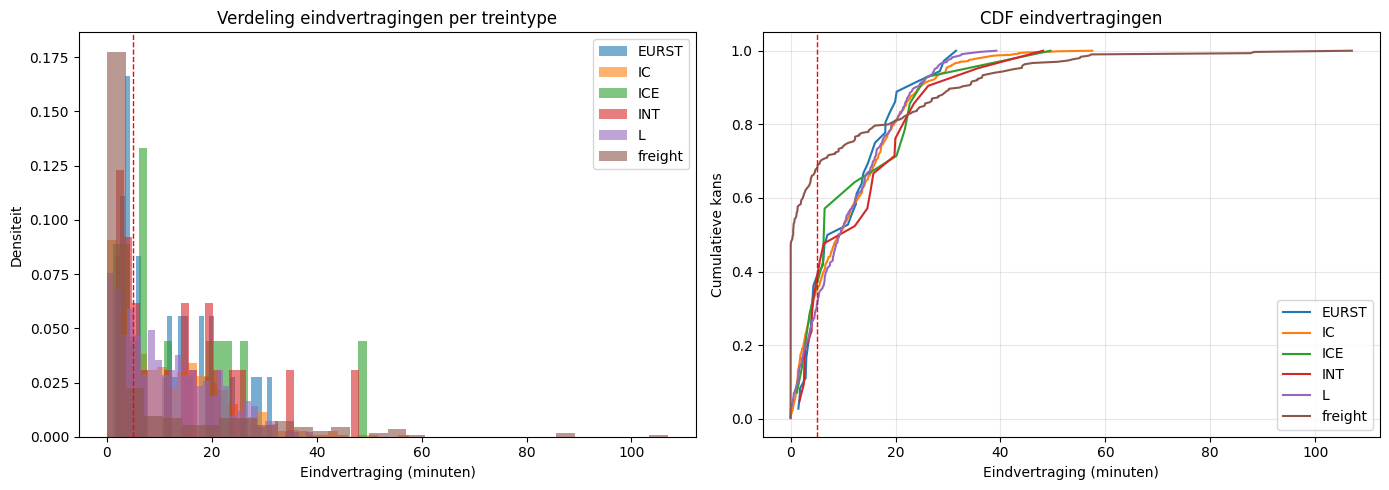

In [9]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Links: histogram van eindvertragingen
ax = axes[0]
for subtype, group in df_delays.groupby('train_subtype'):
    delays = group['final_delay_min']
    ax.hist(delays, bins=30, alpha=0.6, label=subtype, density=True)
ax.set_xlabel('Eindvertraging (minuten)')
ax.set_ylabel('Densiteit')
ax.set_title('Verdeling eindvertragingen per treintype')
ax.legend()
ax.axvline(5, color='red', linestyle='--', linewidth=1, label='5 min drempel')

# Rechts: CDF van eindvertragingen
ax = axes[1]
for subtype, group in df_delays.groupby('train_subtype'):
    delays = group['final_delay_min'].sort_values()
    cdf    = np.arange(1, len(delays) + 1) / len(delays)
    ax.plot(delays, cdf, label=subtype)
ax.set_xlabel('Eindvertraging (minuten)')
ax.set_ylabel('Cumulatieve kans')
ax.set_title('CDF eindvertragingen')
ax.legend()
ax.axvline(5, color='red', linestyle='--', linewidth=1)
ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

### 4.4 Visualisatie: vertraging over de dag

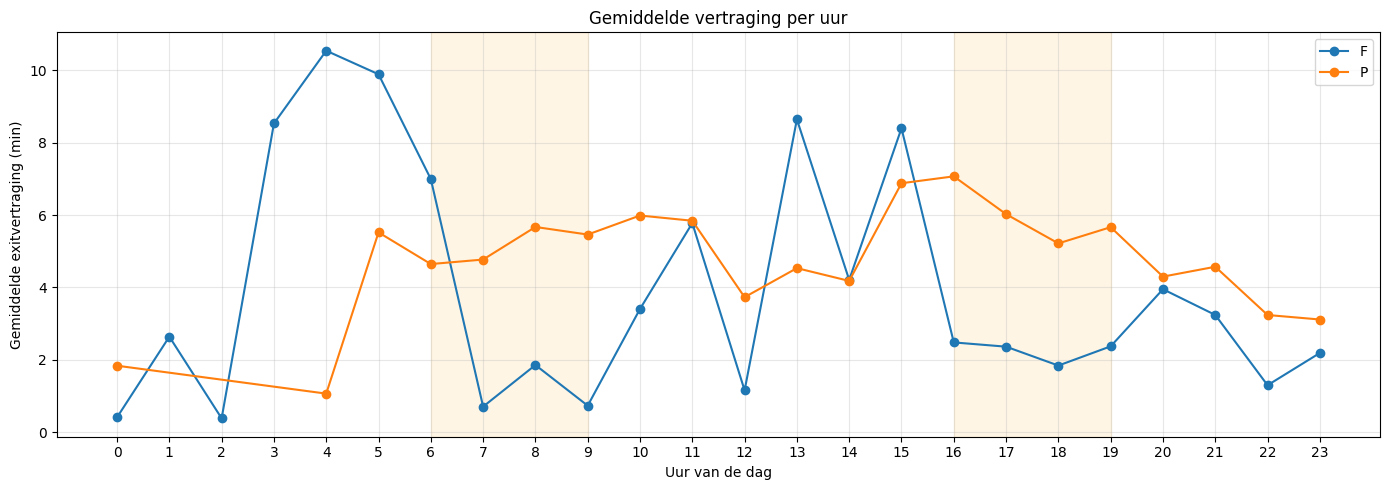

In [10]:
# Vertraging per uur van de dag
df['hour'] = (df['planned_entry'] % 86400) / 3600
df['hour_bin'] = df['hour'].astype(int)

hourly = df.groupby(['hour_bin', 'train_type'])['exit_delay'].mean().reset_index()
hourly['exit_delay_min'] = hourly['exit_delay'] / 60

fig, ax = plt.subplots(figsize=(14, 5))
for train_type, group in hourly.groupby('train_type'):
    ax.plot(group['hour_bin'], group['exit_delay_min'], marker='o', label=train_type)

ax.set_xlabel('Uur van de dag')
ax.set_ylabel('Gemiddelde exitvertraging (min)')
ax.set_title('Gemiddelde vertraging per uur')
ax.set_xticks(range(0, 24))
ax.legend()
ax.grid(True, alpha=0.3)

# Periodes aanduiden
for start, end, label in [(6,9,'Morning Peak'), (16,19,'Evening Peak')]:
    ax.axvspan(start, end, alpha=0.1, color='orange', label=label)

plt.tight_layout()
plt.show()

### 4.5 Controller samenvatting

In [11]:
summary = controller.summary()
print('=== Controller activiteit ===')
for key, val in summary.items():
    print(f'  {key:<20}: {val}')

=== Controller activiteit ===
  n_rescheduled       : 92
  n_fcfs_fallback     : 0
  n_skipped           : 11096
  total_steps         : 11188


### 4.6 Sanity checks

In [12]:
n_finished  = sum(1 for t_id in trains if state.is_finished(t_id))
n_total     = len(trains)
pct_finished = n_finished / n_total * 100

print(f'Treinen voltooid: {n_finished}/{n_total} ({pct_finished:.1f}%)')

# Check: geen enkel segment heeft overlappende bezetting
overlaps = 0
for seg_id in segments:
    entries = [
        (state.actual_entry(t_id, seg_id), state.actual_exit(t_id, seg_id))
        for t_id in trains
        if seg_id in trains[t_id].path
        and seg_id in df[df['train_id'] == t_id]['segment_id'].values
    ]
    entries = [(e, x) for e, x in entries if e is not None and x is not None]
    entries.sort()
    for i in range(len(entries) - 1):
        if entries[i][1] > entries[i+1][0] + 0.001:
            overlaps += 1

print(f'Segmentoverlappen: {overlaps}  (verwacht: 0)')

# Check: simulatietijd consistent
print(f'Eindtijd simulatie: {state.current_time:.0f}s ({state.current_time/3600:.2f}u)')

Treinen voltooid: 1328/1328 (100.0%)
Segmentoverlappen: 0  (verwacht: 0)
Eindtijd simulatie: 87456s (24.29u)


## 5. Opslaan resultaten (optioneel)

In [13]:
# Uncomment om resultaten op te slaan
# df.to_parquet('data/results/simulation_results.parquet', index=False)
# df_delays.to_parquet('data/results/final_delays.parquet', index=False)
# print('Resultaten opgeslagen')